In [1]:
import requests
import pandas as pd
from io import StringIO
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt

In [2]:
# fetches a tab delimited file from the USGS NWIS API with the specified parameters
url = "https://waterservices.usgs.gov/nwis/site/?format=rdb&stateCd=ak&startDT=1950-01-01&endDT=2026-05-06&siteStatus=all&siteType=ST&parameterCd=00060&hasDataTypeCd=dv&outputDataTypeCd=dv"
response = requests.get(url)
# check if the request was successful
if response.status_code == 200:
    # print the content of the response
    print(response.text)
else:    print(f"Failed to fetch data. Status code: {response.status_code}")

#
#
# US Geological Survey
# retrieved: 2026-05-07 12:12:23 -04:00	(sdas01)
#
# The Site File stores location and general information about groundwater,
# surface water, and meteorological sites
# for sites in USA.
#
# File-format description:  http://help.waterdata.usgs.gov/faq/about-tab-delimited-output
# Automated-retrieval info: http://waterservices.usgs.gov/rest/Site-Service.html
#
# Contact:   gs-w_support_nwisweb@usgs.gov
#
# The following selected fields are included in this output:
#
#  agency_cd       -- Agency
#  site_no         -- Site identification number
#  station_nm      -- Site name
#  site_tp_cd      -- Site type
#  dec_lat_va      -- Decimal latitude
#  dec_long_va     -- Decimal longitude
#  coord_acy_cd    -- Latitude-longitude accuracy
#  dec_coord_datum_cd -- Decimal Latitude-longitude datum
#  alt_va          -- Altitude of Gage/land surface
#  alt_acy_va      -- Altitude accuracy
#  alt_datum_cd    -- Altitude datum
#  huc_cd          -- Hydrologic unit code
#

In [3]:
# parse the table into a pandas dataframe
data = StringIO(response.text)
df = pd.read_csv(data, sep="\t", comment="#")
print(df.head())

# get rid of the 5s	15s	50s	7s	16s	16s	1s	10s	8s	3s	10s	16s	2s	5s	5s	5n	30s	3s	3s	5n	4n	20d	20d	5n rows at the end of the dataframe
df = df[~df["site_no"].str.contains("s|n|d")]
print(df.head())


  agency_cd   site_no            station_nm site_tp_cd dec_lat_va  \
0        5s       15s                   50s         7s        16s   
1      USGS  15008000  SALMON R NR HYDER AK         ST  56.026111   
2      USGS  15008000  SALMON R NR HYDER AK         ST  56.026111   
3      USGS  15008000  SALMON R NR HYDER AK         ST  56.026111   
4      USGS  15008000  SALMON R NR HYDER AK         ST  56.026111   

   dec_long_va coord_acy_cd dec_coord_datum_cd alt_va alt_acy_va  ... stat_cd  \
0          16s           1s                10s     8s         3s  ...      5s   
1  -130.065278            R              NAD83  286.0        0.1  ...   00001   
2  -130.065278            R              NAD83  286.0        0.1  ...   00002   
3  -130.065278            R              NAD83  286.0        0.1  ...   00003   
4  -130.065278            R              NAD83  286.0        0.1  ...   00003   

    ts_id loc_web_ds medium_grp_cd parm_grp_cd   srs_id access_cd  begin_date  \
0      5n        

In [4]:
# group by site number, taking the minimum start date and maximum end date for each site
# allows nulls for start and/or end dates
# keep: 
#       station_nm (Site name)
#       site_tp_cd (Site type)
#       dec_lat_va (Decimal latitude)
#       dec_long_va (Decimal longitude)

site_dates = df.groupby("site_no").agg({
    "begin_date": "min",
    "end_date": "max",
    "station_nm": "first",
    "site_tp_cd": "first",
    "dec_lat_va": "first",
    "dec_long_va": "first"
}).reset_index()

print(site_dates.head())

    site_no  begin_date    end_date               station_nm site_tp_cd  \
0  15008000  1963-08-01  2026-05-07     SALMON R NR HYDER AK         ST   
1  15009000  2007-08-01  2016-12-31      SOULE R NR HYDER AK         ST   
2  15011500  1963-08-01  1978-09-30   RED R NR METLAKATLA AK         ST   
3  15011870  1977-09-01  1984-09-30  WHITE C NR KETCHIKAN AK         ST   
4  15011880  1977-08-30  1984-10-26   KETA R NR KETCHIKAN AK         ST   

    dec_lat_va   dec_long_va  
0    56.026111   -130.065278  
1  55.83302857  -130.1833693  
2   55.1410564   -130.532243  
3   55.4138425  -130.4622504  
4   55.3532874  -130.4505824  


In [5]:
# show sites with null start or end dates
null_dates = site_dates[site_dates["begin_date"].isnull() | site_dates["end_date"].isnull()]
print(null_dates)

Empty DataFrame
Columns: [site_no, begin_date, end_date, station_nm, site_tp_cd, dec_lat_va, dec_long_va]
Index: []


In [6]:
# sites with end dates in 2025 or 2026 - we will consider these "active" sites
active_sites = site_dates[site_dates["end_date"].str.contains("2025|2026")]
# sites with end dates before 2025 - we will consider these "inactive" sites
inactive_sites = site_dates[~site_dates["end_date"].str.contains("2025|2026")]

In [7]:
active_sites

,site_no,begin_date,end_date,station_nm,site_tp_cd,dec_lat_va,dec_long_va
0,15008000,1963-08-01,2026-05-07,SALMON R NR HYDER AK,ST,56.026111,-130.065278
7,15015595,2003-04-30,2026-04-29,UNUK R BL BLUE R NR WRANGELL AK,ST,56.240556,-130.880278
9,15019990,1979-10-01,2026-05-06,TYEE LK OUTLET NR WRANGELL AK,ST,56.1996415,-131.5083622
14,15024800,1976-07-28,2026-05-07,STIKINE R NR WRANGELL AK,ST,56.7079243,-132.1319708
23,15041200,1987-07-23,2026-05-06,TAKU R NR JUNEAU AK,ST,58.538611,-133.7
...,...,...,...,...,...,...,...
474,15747000,1984-09-11,2026-05-06,WULIK R BL TUTAK C NR KIVALINA AK,ST,67.87547519,-163.677559
485,15875000,2002-08-21,2025-06-21,COLVILLE R AT UMIAT AK,ST,69.3605,-152.1226944
487,15896000,1971-05-31,2025-12-01,KUPARUK R NR DEADHORSE AK,ST,70.2813799,-148.962861
491,15905100,2010-10-01,2026-05-06,ATIGUN R BL GALBRAITH LK NR PUMP STATION 4 AK,ST,68.4522222,-149.3733333


In [8]:
inactive_sites

,site_no,begin_date,end_date,station_nm,site_tp_cd,dec_lat_va,dec_long_va
1,15009000,2007-08-01,2016-12-31,SOULE R NR HYDER AK,ST,55.83302857,-130.1833693
2,15011500,1963-08-01,1978-09-30,RED R NR METLAKATLA AK,ST,55.1410564,-130.532243
3,15011870,1977-09-01,1984-09-30,WHITE C NR KETCHIKAN AK,ST,55.4138425,-130.4622504
4,15011880,1977-08-30,1984-10-26,KETA R NR KETCHIKAN AK,ST,55.3532874,-130.4505824
5,15011894,1981-02-10,1984-09-30,BLOSSOM R NR KETCHIKAN AK,ST,55.42578169,-130.5628063
...,...,...,...,...,...,...,...
495,15955000,2008-06-23,2012-09-30,CANNING R AB STAINES R NR DEADHORSE AK,ST,69.8817052,-146.3886988
496,15960000,2008-06-01,2012-09-30,TAMAYARIAK R NR KAKTOVIK AK,ST,69.8650563,-145.5955922
497,15975000,1958-06-29,1958-08-31,CHAMBERLIN C NR BARTER ISLAND AK,ST,69.29139878,-144.9666464
498,15976000,1958-06-23,1958-09-01,NERUOKPUKKOONGA C NR BARTER ISLAND AK,ST,69.3080663,-145.0277593


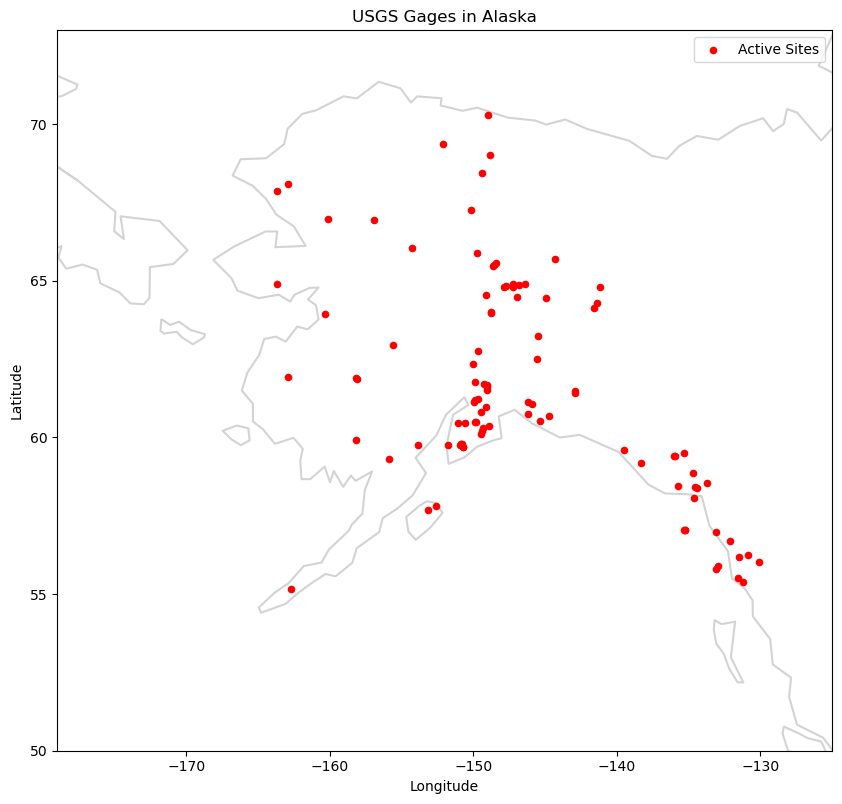

In [9]:
# plot active and inactive sites on a map
active_sites_gdf = gpd.GeoDataFrame(
    active_sites,
    geometry=gpd.points_from_xy(active_sites["dec_long_va"], active_sites["dec_lat_va"]),
    crs="EPSG:4326"
)

inactive_sites_gdf = gpd.GeoDataFrame(
    inactive_sites,
    geometry=gpd.points_from_xy(inactive_sites["dec_long_va"], inactive_sites["dec_lat_va"]),
    crs="EPSG:4326"
)

coastline = gpd.read_file("/import/home/jdpaul3/scratch/ne_110m_coastline.shp").to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))
coastline.plot(ax=ax, color="lightgray", zorder=0)
#inactive_sites_gdf.plot(ax=ax, color="black", markersize=20, label="Inactive Sites", zorder=1, alpha=0.5)
active_sites_gdf.plot(ax=ax, color="red", markersize=20, label="Active Sites", zorder=2)
plt.legend()
plt.title("USGS Gages in Alaska")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

ax.set_xlim(-179, -125)
ax.set_ylim(50, 73)

plt.show()

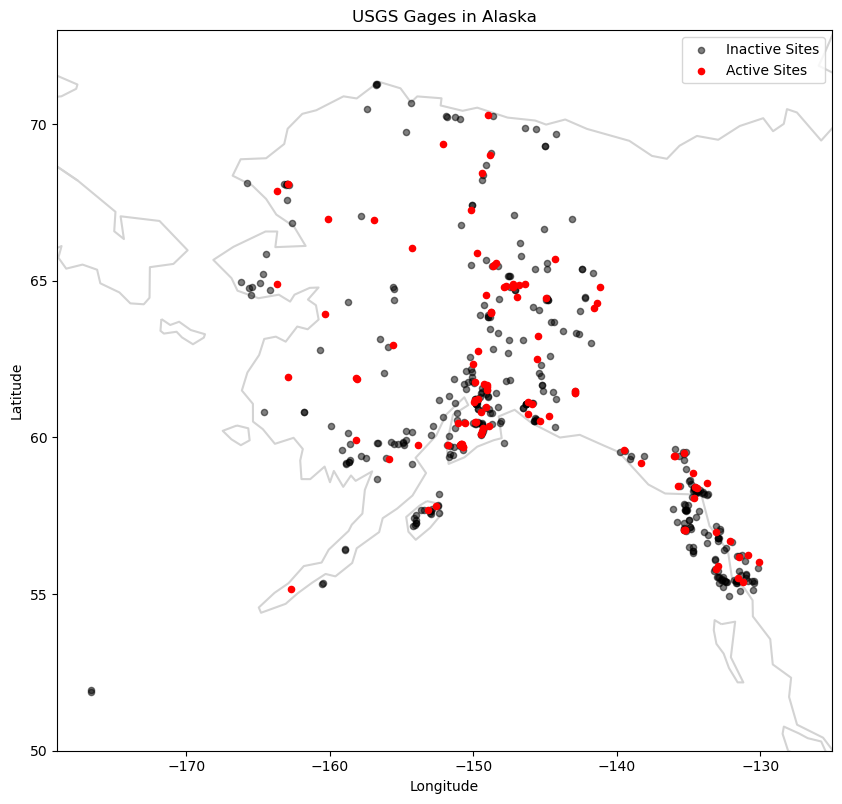

In [10]:
# plot active and inactive sites on a map
active_sites_gdf = gpd.GeoDataFrame(
    active_sites,
    geometry=gpd.points_from_xy(active_sites["dec_long_va"], active_sites["dec_lat_va"]),
    crs="EPSG:4326"
)

inactive_sites_gdf = gpd.GeoDataFrame(
    inactive_sites,
    geometry=gpd.points_from_xy(inactive_sites["dec_long_va"], inactive_sites["dec_lat_va"]),
    crs="EPSG:4326"
)

coastline = gpd.read_file("/import/home/jdpaul3/scratch/ne_110m_coastline.shp").to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))
coastline.plot(ax=ax, color="lightgray", zorder=0)
inactive_sites_gdf.plot(ax=ax, color="black", markersize=20, label="Inactive Sites", zorder=1, alpha=0.5)
active_sites_gdf.plot(ax=ax, color="red", markersize=20, label="Active Sites", zorder=2)
plt.legend()
plt.title("USGS Gages in Alaska")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

ax.set_xlim(-179, -125)
ax.set_ylim(50, 73)

plt.show()

In [11]:
# export active gages as shapefile
active_sites_gdf.to_file("/import/home/jdpaul3/arctic_rivers/processing/ak_gages/ak_active_gages.shp")

/tmp/ipykernel_1427529/1953499781.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  active_sites_gdf.to_file("/import/home/jdpaul3/arctic_rivers/processing/ak_gages/ak_active_gages.shp")


In [12]:
# export inactive gages as shapefile
inactive_sites_gdf.to_file("/import/home/jdpaul3/arctic_rivers/processing/ak_gages/ak_inactive_gages.shp")

/tmp/ipykernel_1427529/2340098637.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  inactive_sites_gdf.to_file("/import/home/jdpaul3/arctic_rivers/processing/ak_gages/ak_inactive_gages.shp")
